In [ ]:

# load files 
from langchain_community.document_loaders import FileSystemBlobLoader
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import PyPDFParser


In [11]:

from langchain_community.document_loaders import FileSystemBlobLoader
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import PyPDFParser

loader = GenericLoader(
    blob_loader=FileSystemBlobLoader(
        path="../",
        glob=f"data/**/*.pdf",
    ),
    blob_parser=PyPDFParser(),
)

docs = loader.load()

Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 14 0 (offset 0)
Ignoring wrong pointing object 21 0 (offset 0)
Ignoring wrong pointing object 27 0 (offset 0)
Ignoring wrong pointing object 37 0 (offset 0)
Ignoring wrong pointing object 47 0 (offset 0)
Ignoring wrong pointing object 53 0 (offset 0)
Ignoring wrong pointing object 55 0 (offset 0)
Ignoring wrong pointing object 57 0 (offset 0)


In [36]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer


chunk_size = 512
tokenizer_name = "intfloat/e5-base-v2"

tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    AutoTokenizer.from_pretrained(tokenizer_name),
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size / 10),
    add_start_index=True,
    strip_whitespace=True,
    separators=".",
)

docs_split = text_splitter.split_documents(docs)

Text(0.5, 0.98, 'Distribution of splitted document lengths in the knowledge base')

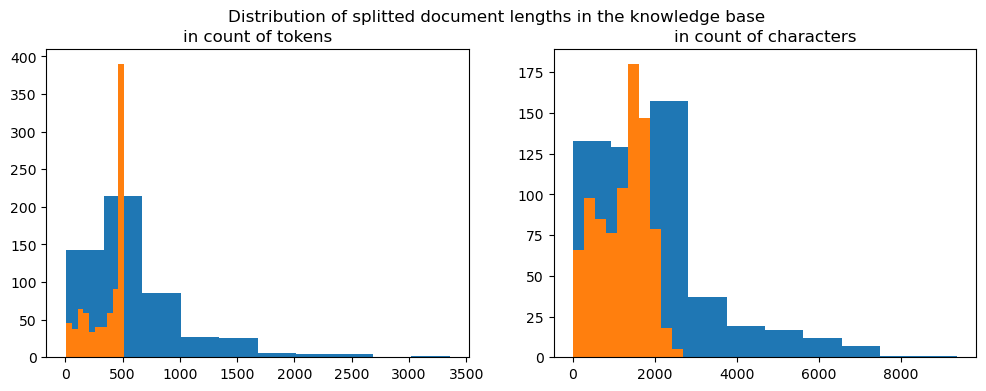

In [38]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1,2, figsize=(12,4))


n_tokens = [len(tokenizer.encode(a.page_content)) for a in docs]
n_tokens_split = [len(tokenizer.encode(a.page_content)) for a in docs_split]
axs[0].hist(n_tokens)
axs[0].hist(n_tokens_split)

axs[0].set_title("in count of tokens")

n_caract = [len(a.page_content) for a in docs]
n_caract_split = [len(a.page_content) for a in docs_split]

axs[1].hist(n_caract)
axs[1].hist(n_caract_split)
axs[1].set_title("in count of characters")

plt.suptitle("Distribution of splitted document lengths in the knowledge base")


In [39]:
from langchain_community.embeddings import HuggingFaceEmbeddings # deprecated
# from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name=tokenizer_name,
    # multi_process=True,
    model_kwargs={"device": "mps"},  # use cuda for faster embeddings on nbidia GPUs
    encode_kwargs={"normalize_embeddings": True},  # Set `True` for cosine similarity
)

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_29697/3187483442.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_split, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

# Save the vector database
from datetime import datetime 
vector_info = str(chunk_size) + "-" + tokenizer_name.replace("/","-") + "-" + datetime.now().date().isoformat()
KNOWLEDGE_VECTOR_DATABASE.save_local("../data/FAISS/{vector_info}")


AttributeError: 'builtin_function_or_method' object has no attribute 'date'